/var/folders/_r/lvddztj50z33ymhxh0h0hszw0000gn/T/ipykernel_18135/3784378695.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  att_numeric = df_att.replace({'Yes': 1, 'No': 0, np.nan: 0})
/var/folders/_r/lvddztj50z33ymhxh0h0hszw0000gn/T/ipykernel_18135/3784378695.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Star Players', y='Placement', data=df_tourney, palette='Set2')


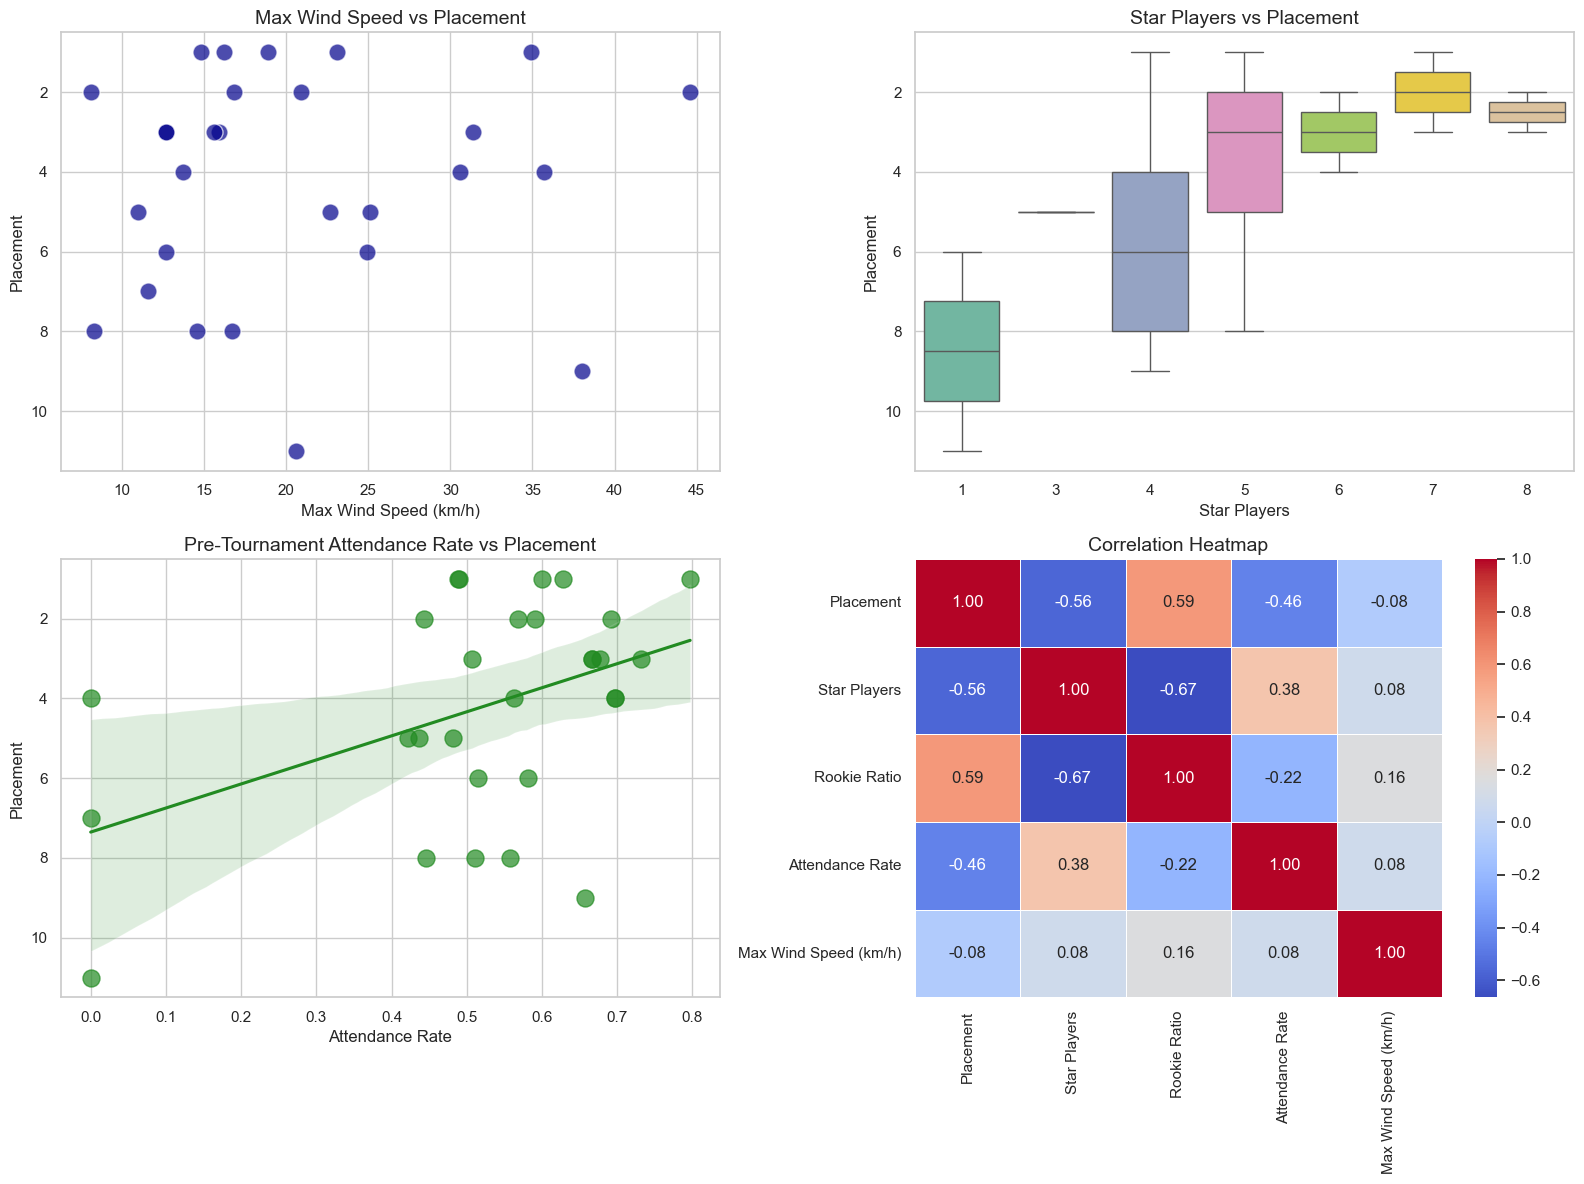

In [5]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

df_tourney = pd.read_csv('tournaments.csv')
df_att = pd.read_csv('attendance.csv')

player_tenures = {
    'Can': {'start': '2000-01-01', 'end': '2024-09-01'},
    'Ceren.oznam': {'start': '2023-10-01', 'end': '2099-01-01'},
    'Tarık': {'start': '2023-10-01', 'end': '2099-01-01'},
    'ekin.yucesan': {'start': '2023-10-01', 'end': '2099-01-01'},
    'zeynepp.menekse': {'start': '2023-10-01', 'end': '2099-01-01'},
    'mert danacı': {'start': '2023-10-01', 'end': '2099-01-01'},
    'murat.suner': {'start': '2023-10-01', 'end': '2099-01-01'},
    'Ahmed Pınarbaşı': {'start': '2024-12-01', 'end': '2099-01-01'},
    'Selin Belet': {'start': '2024-12-01', 'end': '2099-01-01'},
    'Aslı Ulubay': {'start': '2024-12-01', 'end': '2099-01-01'},
    'Alphan Demir': {'start': '2024-12-01', 'end': '2099-01-01'},
    'Faruk Selim Gülcan': {'start': '2024-12-01', 'end': '2099-01-01'},
    'M.Ali': {'start': '2024-12-01', 'end': '2099-01-01'},
    'Kerem Altunbaş': {'start': '2024-12-01', 'end': '2099-01-01'},
    'deniz.ebil': {'start': '2026-02-01', 'end': '2099-01-01'},
    'Nehir.kaya': {'start': '2026-02-01', 'end': '2099-01-01'},
    'Mustafa Kayrak': {'start': '2026-02-01', 'end': '2099-01-01'},
    'Duru Bağcıer': {'start': '2026-02-01', 'end': '2099-01-01'},
    'can.altun': {'start': '2026-02-01', 'end': '2099-01-01'},
    'Banu Köksal': {'start': '2026-02-01', 'end': '2099-01-01'},
    'Yiğit Yusuf Devrim': {'start': '2026-02-01', 'end': '2099-01-01'},
    'Murat Atasoyu': {'start': '2026-02-01', 'end': '2099-01-01'},
    'efe.bayar': {'start': '2026-02-01', 'end': '2099-01-01'}
}

df_tourney.rename(columns={
    'Placement (Sadece Sayı)': 'Placement', 
    'Çaylak Sayısı (1 Yıl ve Altı)': 'Rookie', 
    'veteran sayısı (2 yıl ve üstü)': 'Veteran',
    'Star Oyuncu Sayısı': 'Star Players'
}, inplace=True)

df_tourney['Rookie Ratio'] = df_tourney['Rookie'] / (df_tourney['Rookie'] + df_tourney['Veteran'])

att_numeric = df_att.replace({'Yes': 1, 'No': 0, np.nan: 0})
date_columns = att_numeric.columns[1:]
date_objects = pd.to_datetime(date_columns)

attendance_rates = []

for t_date_str in df_tourney['Kesin Tarih (YYYY-AA-GG)']:
    t_date = pd.to_datetime(t_date_str)
    t_minus_21 = t_date - timedelta(days=21)
    
    valid_dates_and_objs = [(col, dt) for col, dt in zip(date_columns, date_objects) if t_minus_21 <= dt < t_date]
    
    if valid_dates_and_objs:
        total_attendance = 0
        total_possible = 0
        
        for valid_date_str, dt in valid_dates_and_objs:
            for idx, row in att_numeric.iterrows():
                player_name = row['Name']
                is_active = True
                
                if player_name in player_tenures:
                    start_date = pd.to_datetime(player_tenures[player_name]['start'])
                    end_date = pd.to_datetime(player_tenures[player_name]['end'])
                    if not (start_date <= dt <= end_date):
                        is_active = False
                
                if is_active:
                    total_possible += 1
                    total_attendance += row[valid_date_str]
                    
        rate = total_attendance / total_possible if total_possible > 0 else 0
        attendance_rates.append(rate)
    else:
        attendance_rates.append(0) 

df_tourney['Attendance Rate'] = attendance_rates

wind_speeds = []

for date_str in df_tourney['Kesin Tarih (YYYY-AA-GG)']:
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude=41.0082&longitude=28.9784&start_date={date_str}&end_date={date_str}&daily=wind_speed_10m_max&timezone=auto"
    try:
        response = requests.get(url).json()
        wind = response['daily']['wind_speed_10m_max'][0]
        wind_speeds.append(wind)
    except:
        wind_speeds.append(None)

df_tourney['Max Wind Speed (km/h)'] = wind_speeds

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.scatterplot(x='Max Wind Speed (km/h)', y='Placement', data=df_tourney, s=150, color='darkblue', alpha=0.7)
plt.title('Max Wind Speed vs Placement', fontsize=14)
plt.ylabel('Placement')
plt.gca().invert_yaxis()

plt.subplot(2, 2, 2)
sns.boxplot(x='Star Players', y='Placement', data=df_tourney, palette='Set2')
plt.title('Star Players vs Placement', fontsize=14)
plt.ylabel('Placement')
plt.gca().invert_yaxis()

plt.subplot(2, 2, 3)
sns.regplot(x='Attendance Rate', y='Placement', data=df_tourney, scatter_kws={'s':150, 'alpha':0.7}, color='forestgreen')
plt.title('Pre-Tournament Attendance Rate vs Placement', fontsize=14)
plt.ylabel('Placement')
plt.gca().invert_yaxis()

plt.subplot(2, 2, 4)
cols_to_correlate = ['Placement', 'Star Players', 'Rookie Ratio', 'Attendance Rate', 'Max Wind Speed (km/h)']
corr = df_tourney[cols_to_correlate].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

#Bu kod google gemini ile yazılmıştır